In [4]:
!apt-get install r-base
!pip install rpy2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.3-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [5]:
!R -e "install.packages('IRkernel'); IRkernel::installspec()"



R version 4.5.3 (2026-03-11) -- "Reassured Reassurer"
Copyright (C) 2026 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> install.packages('IRkernel'); IRkernel::installspec()
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/IRkernel_1.3.2.tar.gz'
Content type 'application/x-gzip' length 45172 bytes (44 KB)
downloaded 44 KB

* installing *source* pac

In [6]:
%load_ext rpy2.ipython

In [7]:
from google.colab import files
uploaded = files.upload()

Saving kyiv_temperature_1940_2025.csv to kyiv_temperature_1940_2025.csv


In [8]:
%%R
weather <- read.csv('kyiv_temperature_1940_2025.csv')
head(weather)



        time temperature_2m_mean temperature_2m_max temperature_2m_min
1 1940-01-01                  NA              -11.5              -16.8
2 1940-01-02               -14.4              -12.8              -16.6
3 1940-01-03               -15.5              -11.9              -17.7
4 1940-01-04                -7.4               -5.1              -11.5
5 1940-01-05                -8.8               -7.0              -12.2
6 1940-01-06                -9.8               -6.7              -12.0


In [9]:
%%R
# Convert time to Date and extract year
weather$time <- as.Date(weather$time)
weather$year <- as.numeric(format(weather$time, '%Y'))

# Create annual average data frame, omitting NAs to ensure valid means
annual_weather <- aggregate(temperature_2m_mean ~ year, data = weather, FUN = mean, na.rm = TRUE)

# Display the first few rows of the processed data
head(annual_weather)



  year temperature_2m_mean
1 1940            5.260822
2 1941            5.333699
3 1942            5.437808
4 1943            7.296164
5 1944            7.988798
6 1945            6.768493


In [24]:
%%R

print(sd(annual_weather$temperature_2m_mean, na.rm = TRUE))
print(range(annual_weather$temperature_2m_mean, na.rm = TRUE))
print(diff(range(annual_weather$temperature_2m_mean, na.rm = TRUE)))

[1] 1.25584
[1]  5.260822 10.991257
[1] 5.730435


  year temperature_2m_max       era
1 1940           8.862295 1940–1982
2 1941           8.623836 1940–1982
3 1942           9.182740 1940–1982
4 1943          11.043288 1940–1982
5 1944          11.398361 1940–1982
6 1945          10.238630 1940–1982


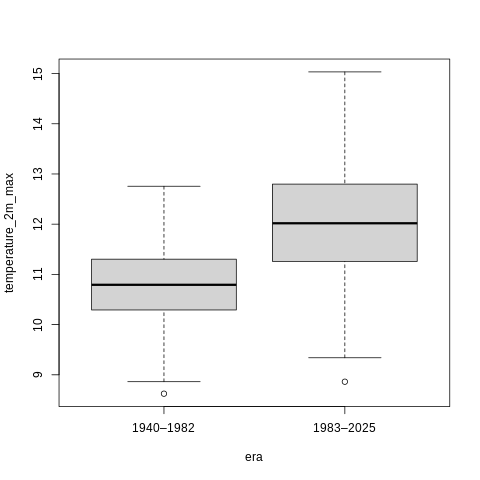

In [11]:
%%R

annual_max <- aggregate(temperature_2m_max ~ year, data = weather, FUN = mean, na.rm = TRUE)

early <- annual_max$temperature_2m_max[annual_max$year <= 1982]
late  <- annual_max$temperature_2m_max[annual_max$year >= 1983]

annual_max$era <- ifelse(annual_max$year <= 1982, "1940–1982", "1983–2025")

print(head(annual_max))

#basic boxplot to visualize data
boxplot(temperature_2m_max ~ era, data = annual_max)



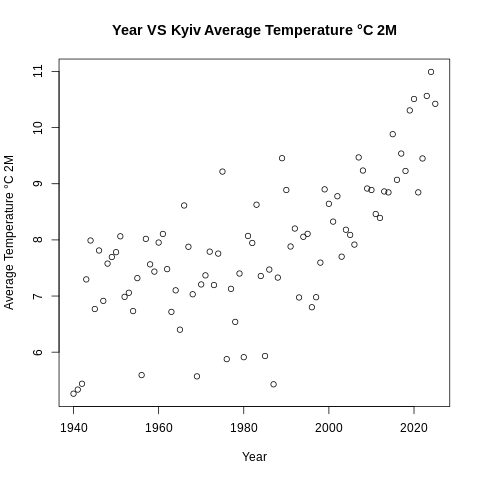

In [12]:
%%R
plot(annual_weather$year, annual_weather$temperature_2m_mean,
     main= "Year VS Kyiv Average Temperature °C 2M",
     xlab = "Year",
     ylab = "Average Temperature °C 2M")


Call:
lm(formula = temperature_2m_mean ~ year, data = annual_weather)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.5924 -0.5087  0.0857  0.6952  1.6928 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -60.631447   7.906278  -7.669 2.78e-11 ***
year          0.034550   0.003988   8.664 2.81e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.918 on 84 degrees of freedom
Multiple R-squared:  0.4719,	Adjusted R-squared:  0.4656 
F-statistic: 75.07 on 1 and 84 DF,  p-value: 2.814e-13



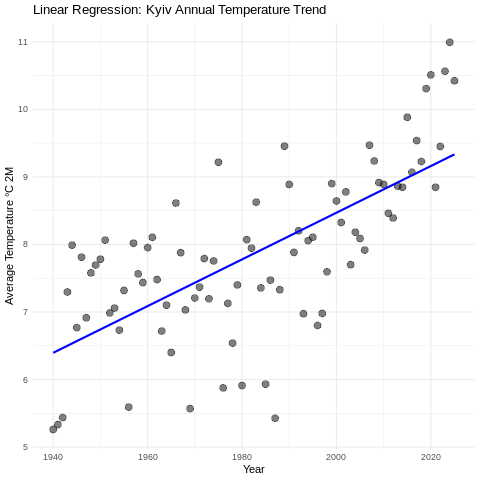

In [13]:
%%R
library(ggplot2)

linModel <- lm(temperature_2m_mean ~ year, data = annual_weather)
print(summary(linModel))

annual_weather$predicted <- predict(linModel, newdata = annual_weather)

ggplot(annual_weather, aes(x = year, y = temperature_2m_mean)) +
  geom_point(size = 3, alpha = 0.5) +
  geom_line(aes(y = predicted), color = "blue", linewidth = 1) +
  theme_minimal() +
  labs(title = "Linear Regression: Kyiv Annual Temperature Trend",
       x = "Year",
       y = "Average Temperature °C 2M")

In [14]:
%%R
cat("--- Summary of Raw Weather Data ---\n")
print(summary(weather))

cat("\n--- Summary of Annual Weather Data ---\n")
print(summary(annual_weather))

--- Summary of Raw Weather Data ---
      time            temperature_2m_mean temperature_2m_max temperature_2m_min
 Min.   :1940-01-01   Min.   :-32.700     Min.   :-29.40     Min.   :-35.600   
 1st Qu.:1961-07-01   1st Qu.:  0.100     1st Qu.:  2.20     1st Qu.: -2.100   
 Median :1982-12-31   Median :  8.500     Median : 12.00     Median :  5.100   
 Mean   :1982-12-31   Mean   :  7.865     Mean   : 11.36     Mean   :  4.427   
 3rd Qu.:2004-07-01   3rd Qu.: 16.600     3rd Qu.: 20.70     3rd Qu.: 12.600   
 Max.   :2025-12-31   Max.   : 30.000     Max.   : 36.30     Max.   : 24.600   
                      NA's   :1                                                
      year     
 Min.   :1940  
 1st Qu.:1961  
 Median :1982  
 Mean   :1982  
 3rd Qu.:2004  
 Max.   :2025  
               

--- Summary of Annual Weather Data ---
      year      temperature_2m_mean   predicted    
 Min.   :1940   Min.   : 5.261      Min.   :6.396  
 1st Qu.:1961   1st Qu.: 7.108      1st Qu.:7.130  


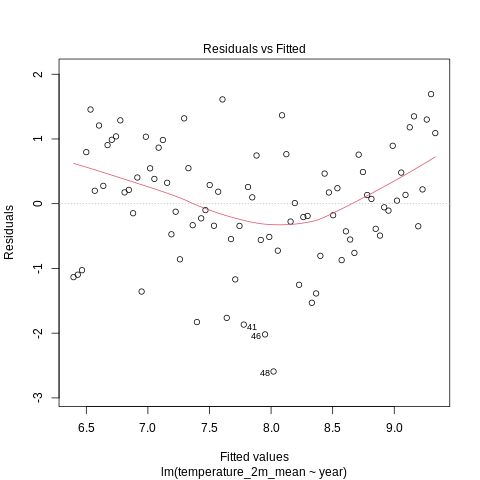

In [15]:
%%R
plot(linModel, which = 1)

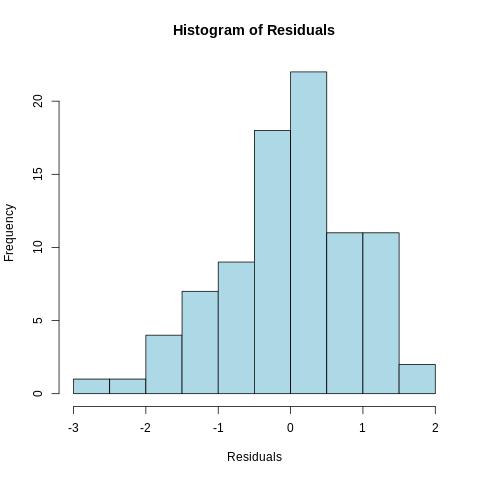

In [16]:
%%R
hist(residuals(linModel),
     main = "Histogram of Residuals",
     xlab = "Residuals",
     col = "lightblue",
     breaks = 15)

In addition: Warning messages:
1: In plot.window(...) : "col.smooth" is not a graphical parameter
2: In plot.xy(xy, type, ...) : "col.smooth" is not a graphical parameter
3: In axis(side = side, at = at, labels = labels, ...) :
  "col.smooth" is not a graphical parameter
4: In axis(side = side, at = at, labels = labels, ...) :
  "col.smooth" is not a graphical parameter
5: In box(...) : "col.smooth" is not a graphical parameter
6: In title(...) : "col.smooth" is not a graphical parameter
7: In title(sub = sub.caption, ...) :
  "col.smooth" is not a graphical parameter


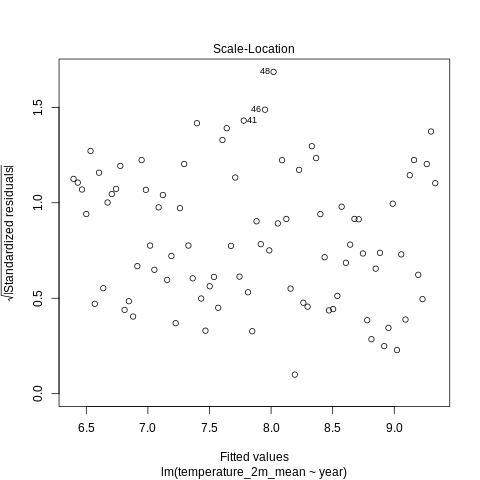

In [17]:
%%R
plot(linModel, which = 3,
     panel = panel.smooth,
     col.smooth = NA)  # makes red line invisible

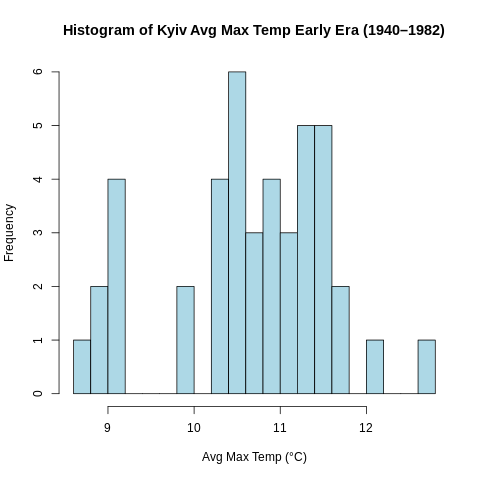

In [18]:
%%R
hist(early,
     main = "Histogram of Kyiv Avg Max Temp Early Era (1940–1982)",
     xlab = "Avg Max Temp (°C)",
     col = "lightblue",
     breaks = 15)




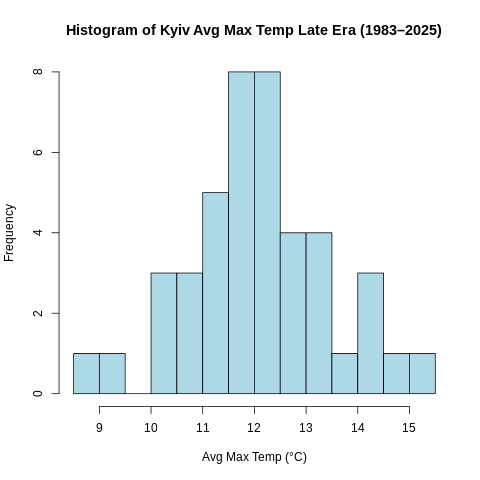

In [19]:
%%R

hist(late,
     main = "Histogram of Kyiv Avg Max Temp Late Era (1983–2025)",
     xlab = "Avg Max Temp (°C)",
     col = "lightblue",
     breaks = 15)

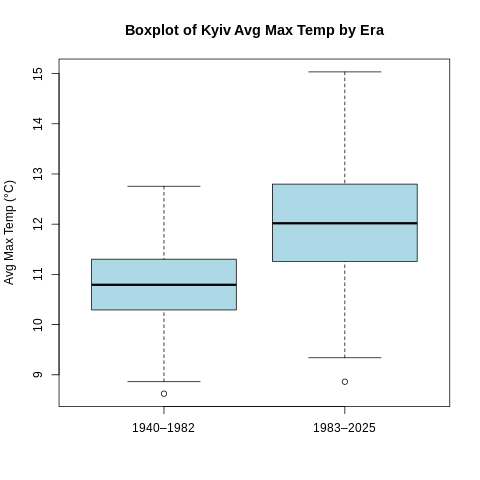

In [20]:
%%R

boxplot(early, late,
        names = c("1940–1982", "1983–2025"),
        main = "Boxplot of Kyiv Avg Max Temp by Era",
        ylab = "Avg Max Temp (°C)",
        col = "lightblue")

In [21]:
%%R

t.test(late, early, alternative = "greater", var.equal=TRUE)



	Two Sample t-test

data:  late and early
t = 5.6905, df = 84, p-value = 9.027e-08
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 1.009349      Inf
sample estimates:
mean of x mean of y 
 12.07031  10.64412 

